# Diseño de Laboratorio — Grafos y Recorridos
## (Implementación de BFS y DFS sobre una red de bodegas)

**Integrantes:**
- Enrique Jara Escobar
- Sergio Alejandro Ariza
- Andres Ricardo Poveda

---

## 1) Descripción del problema
Una empresa de distribución dispone de **8 bodegas** (A–H) conectadas por rutas directas formando una red. Se requiere:

1. **Representar** la red como un grafo no dirigido usando **lista de adyacencia**.
2. **Recorrer** la red desde la bodega A usando **BFS** (búsqueda por anchura) y **DFS** (búsqueda por profundidad).
3. **Comparar** los resultados de ambos recorridos y analizar cuándo conviene cada uno.
4. **Modificar** la red agregando una nueva bodega I conectada a E y H, y volver a ejecutar los recorridos.

**Aristas iniciales de la red:**
A-B, A-C, B-D, B-E, C-F, C-G, D-H, E-F, G-H

## 2) Requerimientos
### Requerimientos funcionales
- **RF1.** El sistema debe crear un grafo vacío representado como lista de adyacencia (diccionario).
- **RF2.** El sistema debe permitir agregar vértices al grafo sin duplicarlos.
- **RF3.** El sistema debe permitir agregar aristas no dirigidas entre dos vértices.
- **RF4.** El sistema debe imprimir la lista de adyacencia ordenada alfabéticamente.
- **RF5.** El sistema debe implementar BFS desde un nodo inicio, mostrando el estado de la cola en cada paso y el recorrido final.
- **RF6.** El sistema debe implementar DFS recursivo desde un nodo inicio, mostrando cada nodo visitado y el recorrido final.
- **RF7.** El sistema debe explorar vecinos en orden alfabético en ambos recorridos.
- **RF8.** El sistema debe permitir agregar una nueva bodega I con aristas I-E e I-H y re-ejecutar BFS y DFS.
- **RF9.** El sistema debe comparar los recorridos antes y después de agregar el nodo I.
- **RF10.** El sistema debe mostrar un análisis aplicado sobre el uso de grafos en redes de distribución.

### Requerimientos no funcionales
- **RNF1.** La única librería externa permitida es `collections.deque` para la cola en BFS.
- **RNF2.** Las operaciones del grafo (insertar vértice/arista, imprimir) deben ser $O(V + E)$ en el peor caso.
- **RNF3.** BFS y DFS deben ejecutarse en $O(V + E)$ donde $V$ = vértices y $E$ = aristas.
- **RNF4.** El código debe estar organizado en funciones con descripción `#` y sin usar `if __name__`.
- **RNF5.** El programa debe ejecutarse de forma lineal (secuencial), siendo legible y sencillo.

## 3) Historias de usuario
A continuación se define **una historia por cada requerimiento funcional**.

1. **HU1 (RF1):** Como desarrollador, quiero una función `crear_grafo()` que devuelva un diccionario vacío para representar la red.
2. **HU2 (RF2):** Como desarrollador, quiero una función `agregar_vertice()` para registrar bodegas sin duplicar entradas.
3. **HU3 (RF3):** Como desarrollador, quiero una función `agregar_arista()` que conecte dos bodegas de forma bidireccional.
4. **HU4 (RF4):** Como operador, quiero ver la lista de adyacencia completa ordenada alphabéticamente para auditar la red.
5. **HU5 (RF5):** Como logístico, quiero BFS desde A mostrando la cola en cada paso para entender el recorrido por niveles.
6. **HU6 (RF6):** Como logístico, quiero DFS desde A mostrando cada visita para entender la exploración por ramas.
7. **HU7 (RF7):** Como evaluador, quiero que los vecinos se exploren en orden alfabético para obtener resultados deterministas.
8. **HU8 (RF8):** Como administrador, quiero agregar la bodega I con conexiones I-E e I-H y ver el grafo actualizado.
9. **HU9 (RF9):** Como analista, quiero comparar los recorridos antes y después de agregar I para medir el impacto del cambio.
10. **HU10 (RF10):** Como estudiante, quiero leer el análisis aplicado para entender la utilidad de grafos en distribución real.

## 4) Diagrama de flujo


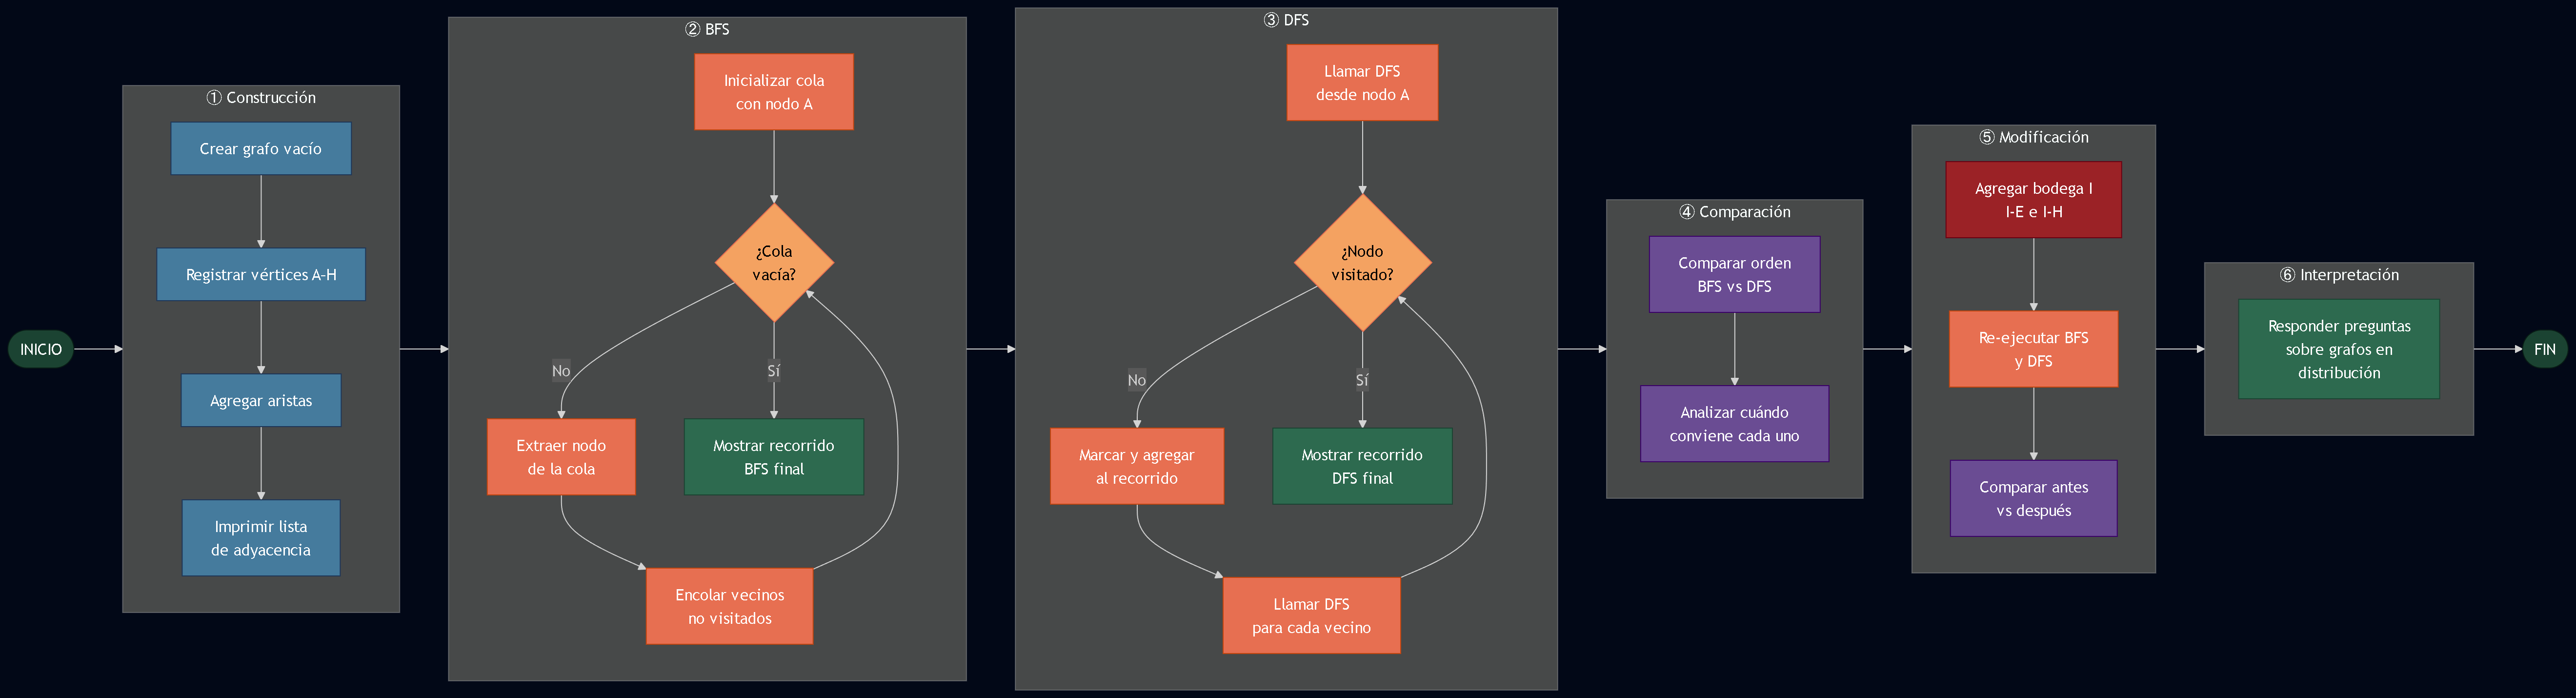

In [1]:
from IPython.display import Image
Image("flujo.png")

## 5) Diagrama de secuencia

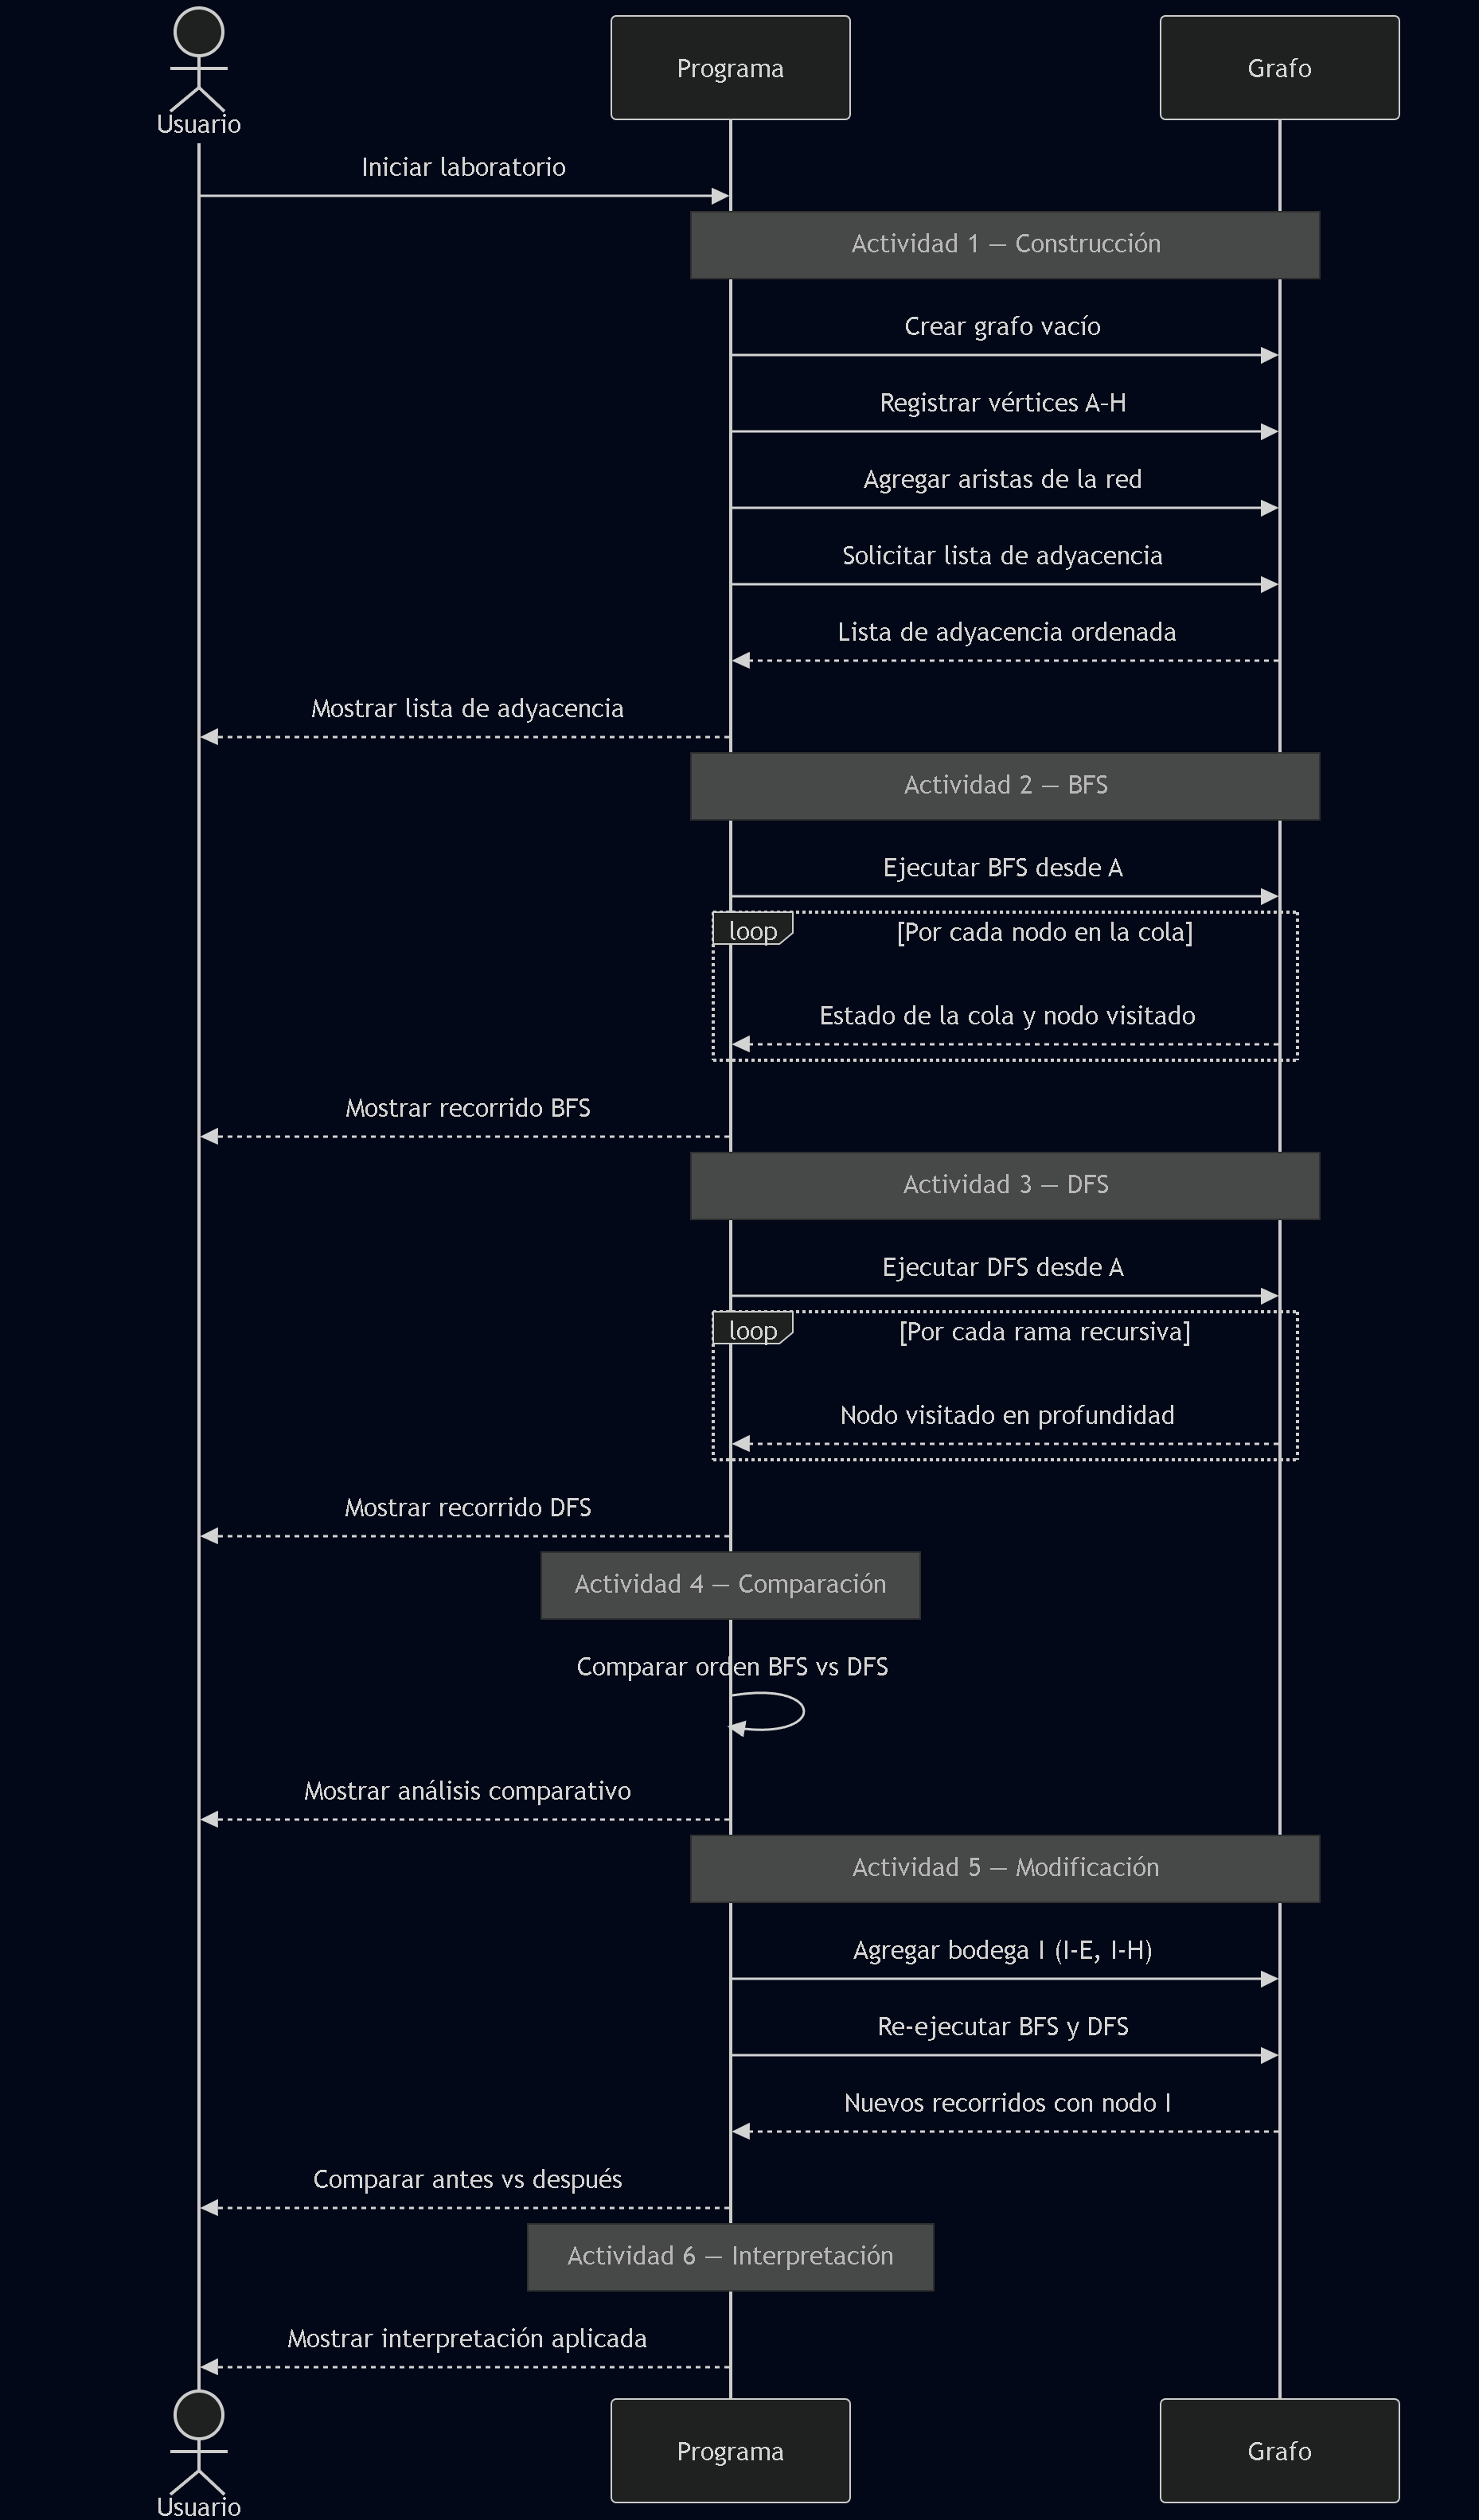

In [2]:
from IPython.display import Image
Image("secuencia.png")

## 6) Diagrama de casos de uso


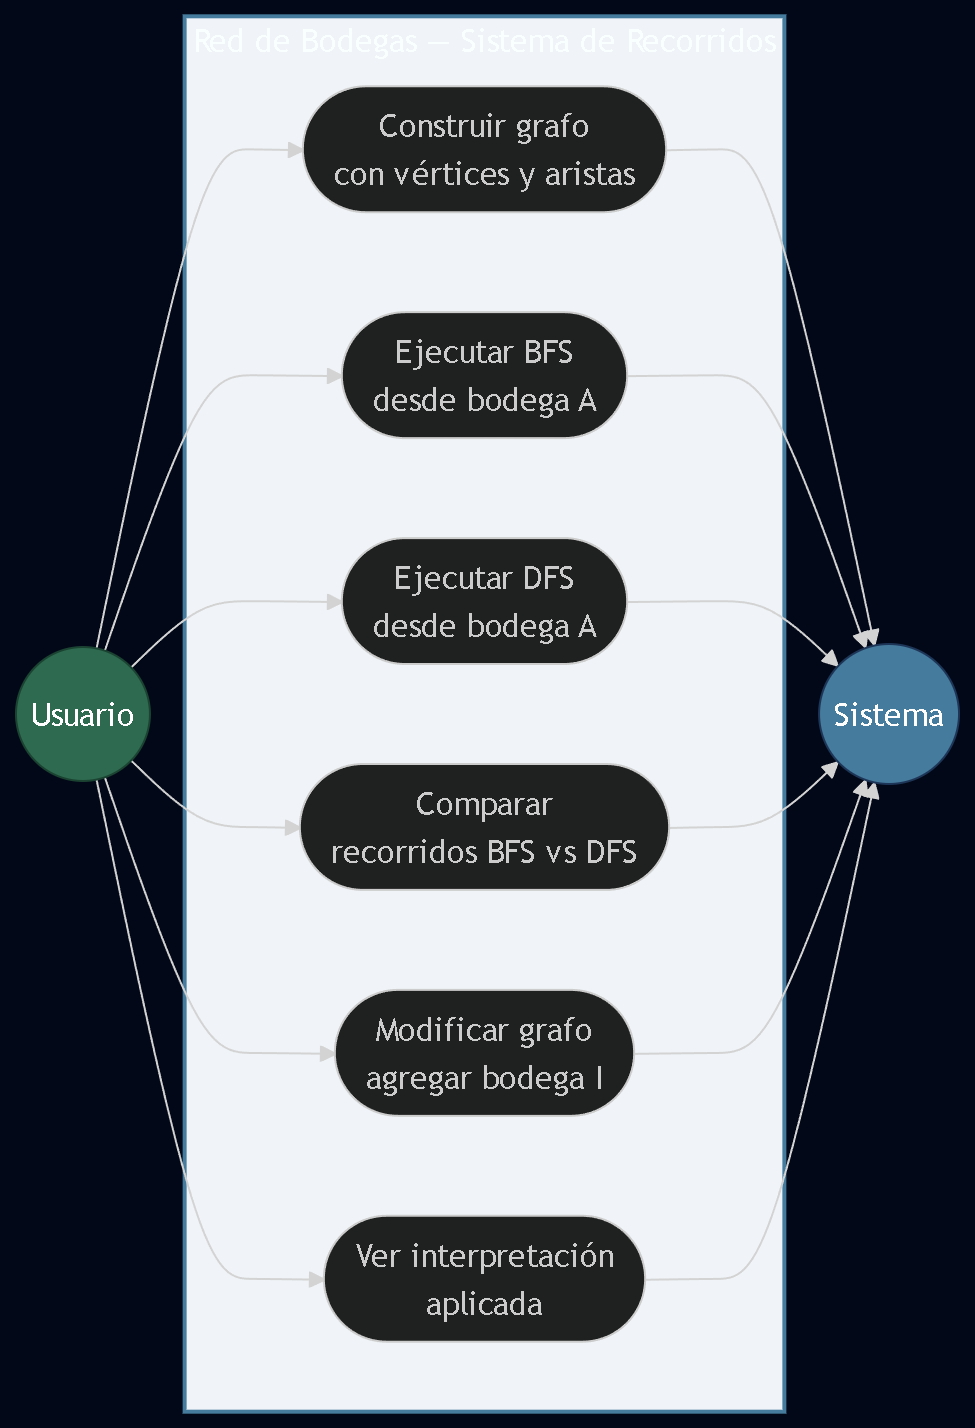

In [3]:
Image("caso.png")

## 7) Análisis de complejidad

### 7.1) Resumen del problema
El programa opera sobre un grafo no dirigido con $V$ vértices y $E$ aristas. Tanto BFS como DFS visitan cada vértice y arista exactamente una vez cuando los nodos están marcados como visitados. El uso de una cola (`deque`) en BFS garantiza operaciones $O(1)$ por enqueue/dequeue.

### 7.2) Tabla compacta de complejidad

| Operación | Función | Tiempo | Espacio |
|---|---|---|---|
| Agregar vértice | `agregar_vertice` | $O(1)$ | $O(1)$ |
| Agregar arista | `agregar_arista` | $O(1)$ amortizado | $O(1)$ |
| Imprimir lista de adyacencia | `imprimir_grafo` | $O(V + E)$ | $O(1)$ |
| BFS completo | `bfs` | $O(V + E)$ | $O(V)$ |
| DFS completo | `dfs` / `_dfs_recursivo` | $O(V + E)$ | $O(V)$ pila de recursión |
| Ordenar vecinos por exploración | `sorted(grafo[nodo])` | $O(d \log d)$ por nodo | $O(d)$ |

Donde $d$ es el grado máximo del nodo. Como $\sum d = 2E$, el costo total de los `sorted` es $O(E \log d)$.

### 7.3) Complejidad total

$$
T_{BFS} = T_{DFS} = O(V + E \log d) \approx O(V + E)
$$

para grafos dispersos donde $d$ es pequeño y constante.

| Escenario | Complejidad temporal | Complejidad espacial |
|---|---|---|
| Grafo disperso ($E \approx V$) | $O(V)$ | $O(V)$ |
| Grafo denso ($E \approx V^2$) | $O(V^2)$ | $O(V)$ |
| Caso general | $O(V + E)$ | $O(V)$ |

### 7.4) Gráficas mejor/peor caso


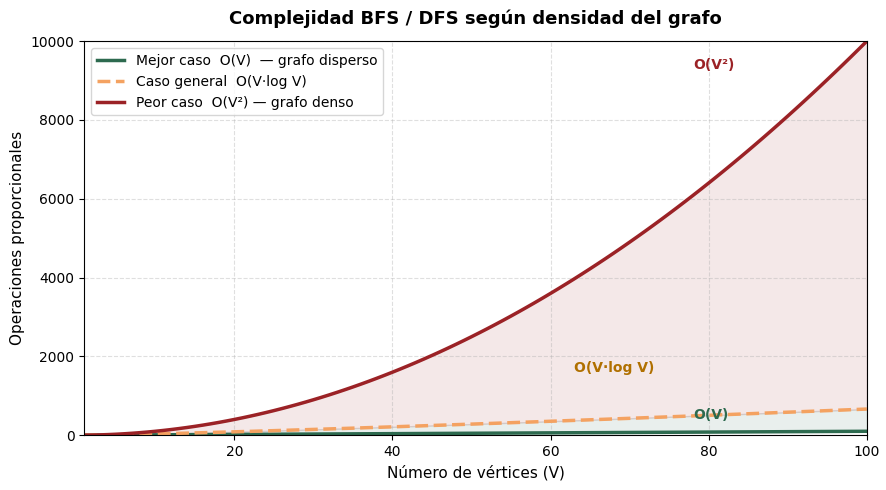

In [4]:
from IPython.display import Image
Image("casos.png")

### 7.5) Conclusión
BFS y DFS tienen la misma complejidad asintótica $O(V + E)$, pero difieren en el orden de visita. BFS garantiza el camino con menor número de aristas (útil para rutas cortas), mientras que DFS es preferible para detectar ciclos, componentes conexas o explorar toda la red antes de retroceder. Para la red de bodegas con $V=9$, $E=11$ (tras agregar I), ambos son prácticamente instantáneos.

## 8) Tests
Conjunto de pruebas propuesto para validar el sistema de grafos y recorridos.

---

### Escenario 1 — Lista de adyacencia correcta
**Descripción:** verifica que al agregar aristas se registren en ambas direcciones y sin duplicados.

**Entrada:** grafo con aristas A-B, A-C, B-D

**Resultado esperado:**
```
A -> ['B', 'C']
B -> ['A', 'D']
C -> ['A']
D -> ['B']
```

---

### Escenario 2 — BFS desde A (grafo inicial A–H)
**Descripción:** valida que BFS recorra nivel por nivel en orden alfabético.

**Resultado esperado:**
```
Recorrido BFS: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
```
*(nivel 0: A — nivel 1: B, C — nivel 2: D, E, F, G — nivel 3: H)*

---

### Escenario 3 — DFS desde A (grafo inicial A–H)
**Descripción:** valida que DFS explore en profundidad por la rama de menor clave alfabética.

**Resultado esperado:**
```
Recorrido DFS: ['A', 'B', 'D', 'H', 'G', 'C', 'F', 'E']
```
*(profundiza por B → D → H → G → retrocede a C → F → E)*

---

### Escenario 4 — Modificación: agregar bodega I
**Descripción:** verifica que al agregar I con conexiones I-E e I-H, el nodo quede en la lista de adyacencia y sea alcanzable por BFS y DFS.

**Resultado esperado (lista de adyacencia parcial):**
```
E -> ['B', 'F', 'I']
H -> ['D', 'G', 'I']
I -> ['E', 'H']
```

**Recorridos actualizados:**
```
BFS: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
DFS: ['A', 'B', 'D', 'H', 'G', 'C', 'F', 'E', 'I']
```

---

### Escenario 5 — Sin aristas duplicadas
**Descripción:** intentar agregar la misma arista dos veces no debe crear entradas repetidas en la lista de adyacencia.

**Resultado esperado:**
```
g["A"].count("B") == 1   →  True
```

## 9) Código funcional
Implementación completa del laboratorio con:

- **Actividad 1:** Grafo con lista de adyacencia, vértices A–H y aristas de la red.
- **Actividad 2:** BFS desde A mostrando cola en cada paso y recorrido final.
- **Actividad 3:** DFS recursivo desde A mostrando cada visita y recorrido final.
- **Actividad 4:** Comparación textual entre BFS y DFS.
- **Actividad 5:** Adición del nodo I (conexiones I-E e I-H) y re-ejecución de recorridos con comparación.
- **Actividad 6:** Respuestas de interpretación aplicada al caso de distribución de bodegas.

In [ ]:
from collections import deque
import sys

# ─────────────────────────────────────────────────────────
# ACTIVIDAD 1 – Construcción del grafo
# ─────────────────────────────────────────────────────────

def crear_grafo():
    """Crea un grafo vacío representado como diccionario (lista de adyacencia)."""
    return {}

def agregar_vertice(grafo, vertice):
    """Agrega un vértice al grafo si aún no existe. Devuelve True si fue añadido."""
    if vertice not in grafo:
        grafo[vertice] = []
        return True
    return False

def agregar_arista(grafo, u, v):
    """Agrega una arista no dirigida entre u y v. Devuelve True si fue añadida."""
    if u == v:
        return False  # No se permiten lazos (self-loops)
    if u not in grafo or v not in grafo:
        return False
    if v not in grafo[u]:
        grafo[u].append(v)
        grafo[v].append(u)
        return True
    return False

def imprimir_grafo(grafo):
    """Imprime la lista de adyacencia ordenada alfabéticamente."""
    if not grafo:
        print("  El grafo está vacío.")
        return
    print("  Lista de adyacencia (grafo no dirigido – bidireccional):")
    print()
    for vertice in sorted(grafo):
        vecinos = sorted(grafo[vertice])
        print(f"  {vertice} <-> {vecinos}")
    print()


def imprimir_visual(grafo):
    """Muestra el grafo con diseño visual de ramas por nodo."""
    if not grafo:
        print("  El grafo está vacío.")
        return
    print("  Representación visual (grafo no dirigido – bidireccional):")
    print()
    for vertice in sorted(grafo):
        vecinos = sorted(grafo[vertice])
        print(f"  [{vertice}]")
        if not vecinos:
            print("   └── (sin conexiones)")
        else:
            for i, vecino in enumerate(vecinos):
                rama = "└──" if i == len(vecinos) - 1 else "├──"
                if vecino == vertice:
                    print(f"   {rama} ↩️")
                else:
                    print(f"   {rama} [{vecino}]")
        print()


def imprimir_matriz_adyacencia(grafo):
    """Muestra la matriz de adyacencia del grafo."""
    if not grafo:
        print("  El grafo está vacío.")
        return
    vertices = sorted(grafo)
    n = len(vertices)
    cw = max(len(v) for v in vertices) + 1  # ancho de celda

    print("  Matriz de adyacencia:")
    print()

    # Encabezado de columnas (alineado con las celdas de datos)
    espacio_header = "  " + " " * (cw + 3)
    cabecera = "  ".join(f"{v:^{cw}}" for v in vertices)
    print(f"{espacio_header}{cabecera}")

    # Línea separadora
    ancho_datos = n * cw + (n - 1) * 2
    print(f"  {'─' * cw} ┼ {'─' * ancho_datos}")

    # Filas de datos
    for fila in vertices:
        celdas = []
        for col in vertices:
            if fila == col and col in grafo[fila]:
                celdas.append(f"{'\u21a9':^{cw}}")
            else:
                val = "1" if col in grafo[fila] else "0"
                celdas.append(f"{val:^{cw}}")
        print(f"  {fila:<{cw}} │ {'  '.join(celdas)}")
    print()


def visualizar_grafo_turtle(grafo):
    """Dibuja el grafo usando turtle graphics. Haga clic en la ventana para cerrar."""
    import turtle
    import math

    if not grafo:
        print("  El grafo está vacío.")
        return

    vertices = sorted(grafo.keys())
    n = len(vertices)

    # Limpiar estado previo de turtle (por si se abrió antes)
    try:
        turtle.bye()
    except Exception:
        pass

    try:
        screen = turtle.Screen()
        screen.title("Grafo – Haga clic en la ventana para cerrar")
        screen.setup(width=800, height=700)
        screen.bgcolor("#f0f4f8")
        screen.tracer(0)  # Desactiva animación para mayor velocidad

        t = turtle.Turtle()
        t.hideturtle()
        t.speed(0)

        # --- Posiciones en círculo ---
        radio = max(150, min(250, 35 * n))
        posiciones = {}
        for i, v in enumerate(vertices):
            ang = 2 * math.pi * i / n - math.pi / 2
            posiciones[v] = (radio * math.cos(ang), radio * math.sin(ang))

        # --- Dibujar aristas ---
        aristas_vistas = set()
        t.pensize(2)
        t.pencolor("#9aa8b8")
        for u in vertices:
            for vecino in sorted(grafo[u]):
                arista = tuple(sorted([u, vecino]))
                if arista not in aristas_vistas:
                    aristas_vistas.add(arista)
                    x1, y1 = posiciones[u]
                    x2, y2 = posiciones[vecino]
                    t.penup()
                    t.goto(x1, y1)
                    t.pendown()
                    t.goto(x2, y2)

        # --- Dibujar nodos ---
        r = 22
        for v in vertices:
            x, y = posiciones[v]
            # Sombra
            t.penup()
            t.goto(x + 3, y - r - 3)
            t.pencolor("#cccccc")
            t.fillcolor("#cccccc")
            t.pendown()
            t.begin_fill()
            t.circle(r)
            t.end_fill()
            # Círculo principal
            t.penup()
            t.goto(x, y - r)
            t.pencolor("#1a5276")
            t.fillcolor("#2e86c1")
            t.pendown()
            t.begin_fill()
            t.circle(r)
            t.end_fill()
            # Etiqueta
            t.penup()
            t.goto(x, y - 9)
            t.pencolor("white")
            t.write(v, align="center", font=("Arial", 13, "bold"))

        # --- Título ---
        num_aristas = sum(len(grafo[v]) for v in grafo) // 2
        t.penup()
        t.goto(0, radio + 60)
        t.pencolor("#1a252f")
        t.write(
            f"Grafo de distribución  |  {n} nodos  ·  {num_aristas} aristas",
            align="center",
            font=("Arial", 13, "bold"),
        )
        # Instrucción de cierre
        t.goto(0, -(radio + 65))
        t.pencolor("#555555")
        t.write(
            "Haga clic en la ventana para cerrar",
            align="center",
            font=("Arial", 10, "normal"),
        )

        screen.update()
        screen.exitonclick()  # Cierra la ventana al hacer clic

    except turtle.Terminator:
        pass  # El usuario cerró la ventana con la X
    except Exception as e:
        print(f"  Error al visualizar con Turtle: {e}\n")
    finally:
        try:
            turtle.bye()
        except Exception:
            pass


# ─────────────────────────────────────────────────────────
# ACTIVIDAD 2 – BFS (Búsqueda por Anchura)
# ─────────────────────────────────────────────────────────

def bfs(grafo, inicio):
    """Recorre el grafo en anchura desde inicio. Muestra la cola en cada paso."""
    if inicio not in grafo:
        print(f"  El nodo '{inicio}' no existe en el grafo.")
        return []

    visitados = set()
    cola = deque([inicio])
    visitados.add(inicio)
    orden = []

    print(f"BFS desde '{inicio}':")
    while cola:
        print(f"  Cola: {list(cola)}")
        nodo = cola.popleft()
        orden.append(nodo)
        print(f"  Visitando: {nodo}")
        for vecino in sorted(grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)

    print(f"  Recorrido BFS: {orden}\n")
    return orden


# ─────────────────────────────────────────────────────────
# ACTIVIDAD 3 – DFS (Búsqueda por Profundidad)
# ─────────────────────────────────────────────────────────

def _dfs_recursivo(grafo, nodo, visitados, orden):
    """Función auxiliar recursiva para DFS."""
    visitados.add(nodo)
    orden.append(nodo)
    print(f"  Visitando: {nodo}")
    for vecino in sorted(grafo[nodo]):
        if vecino not in visitados:
            _dfs_recursivo(grafo, vecino, visitados, orden)

def dfs(grafo, inicio):
    """Inicia el recorrido DFS desde inicio y devuelve el orden de visita."""
    if inicio not in grafo:
        print(f"  El nodo '{inicio}' no existe en el grafo.")
        return []

    visitados = set()
    orden = []
    print(f"DFS desde '{inicio}':")
    _dfs_recursivo(grafo, inicio, visitados, orden)
    print(f"  Recorrido DFS: {orden}\n")
    return orden


# ─────────────────────────────────────────────────────────
# ACTIVIDAD 4 – Comparación BFS vs DFS
# ─────────────────────────────────────────────────────────

def comparar_recorridos(orden_bfs, orden_dfs):
    """Compara los recorridos BFS y DFS e imprime un análisis textual."""
    print("─" * 45)
    print("ACTIVIDAD 4 – Comparación BFS vs DFS")
    print("─" * 45)
    print(f"  BFS: {orden_bfs}")
    print(f"  DFS: {orden_dfs}")
    print()
    print("  BFS recorre nivel por nivel (anchura).")
    print("  Es útil para hallar el camino con menor")
    print("  número de conexiones (ruta más corta).")
    print()
    print("  DFS profundiza por una rama antes de")
    print("  retroceder. Es útil para explorar todos")
    print("  los caminos posibles o detectar ciclos.")
    print()


# ─────────────────────────────────────────────────────────
# ACTIVIDAD 6 – Interpretación aplicada
# ─────────────────────────────────────────────────────────

def interpretacion_aplicada():
    """Imprime las respuestas de interpretación sobre el caso de distribución."""
    print("─" * 45)
    print("ACTIVIDAD 6 – Interpretación aplicada")
    print("─" * 45)
    print("1. Un grafo modela bodegas como vértices y rutas")
    print("   de distribución como aristas, facilitando")
    print("   visualizar conexiones y planificar envíos.")
    print()
    print("2. BFS encuentra la ruta con menos saltos porque")
    print("   explora nivel a nivel, garantizando el camino")
    print("   más corto en número de conexiones.")
    print()
    print("3. DFS explora cada rama hasta el final antes de")
    print("   retroceder, cubriendo toda la red sin importar")
    print("   la distancia; ideal para auditar conexiones.")
    print()
    print("4. Programar los recorridos permite automatizar")
    print("   análisis en redes grandes, evita errores")
    print("   humanos y escala fácilmente ante cambios.")
    print()
    print("5. Otro contexto real: redes sociales (amigos")
    print("   recomendados), GPS (rutas en mapas), internet")
    print("   (enrutamiento de paquetes).")
    print()


# ─────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────

def inicializar_grafo_defecto():
    """Construye el grafo inicial con vértices A–H y las aristas del enunciado."""
    grafo = crear_grafo()
    for v in ["A", "B", "C", "D", "E", "F", "G", "H"]:
        agregar_vertice(grafo, v)
    for u, v in [
        ("A", "B"), ("A", "C"),
        ("B", "D"), ("B", "E"),
        ("C", "F"), ("E", "G"),
        ("F", "H"), ("G", "H"),
    ]:
        agregar_arista(grafo, u, v)
    return grafo

def pedir_nodo(grafo, prompt, default=None):
    """
    Solicita un nodo al usuario y valida que exista en el grafo.
    Si se proporciona un default y el usuario no escribe nada, devuelve el default.
    """
    sufijo = f" [Enter = {default}]" if default else ""
    while True:
        try:
            entrada = input(f"  {prompt}{sufijo}: ").strip().upper()
        except (EOFError, KeyboardInterrupt):
            print()
            return default if default else None

        if not entrada:
            if default and default in grafo:
                return default
            if default and default not in grafo:
                print(f"  Nodo por defecto '{default}' no existe. "
                      f"Disponibles: {sorted(grafo.keys())}")
                continue
            print(f"  Entrada vacía. Disponibles: {sorted(grafo.keys())}")
            continue

        if entrada not in grafo:
            print(f"  El nodo '{entrada}' no existe. "
                  f"Disponibles: {sorted(grafo.keys())}")
            continue

        return entrada


# ─────────────────────────────────────────────────────────
# OPCIONES DEL MENÚ
# ─────────────────────────────────────────────────────────

def opcion_actividad1(grafo):
    while True:
        print("─" * 45)
        print("ACTIVIDAD 1 – Ver grafo")
        print("─" * 45)
        print("  a. Representación visual (texto)")
        print("  b. Lista de adyacencia")
        print("  c. Matriz de adyacencia")
        print("  d. Visualización gráfica (Turtle)")
        print("  0. Regresar al menú")
        print("─" * 45)
        try:
            sub = input("  Opción: ").strip().lower()
        except (EOFError, KeyboardInterrupt):
            print()
            break
        print()
        if sub == "a":
            imprimir_visual(grafo)
        elif sub == "b":
            imprimir_grafo(grafo)
        elif sub == "c":
            imprimir_matriz_adyacencia(grafo)
        elif sub == "d":
            visualizar_grafo_turtle(grafo)
        elif sub == "0":
            break
        else:
            print(f"  Opción '{sub}' no válida. Use a, b, c, d ó 0.\n")

def opcion_actividad2(grafo):
    print("─" * 45)
    print("ACTIVIDAD 2 – BFS")
    print("─" * 45)
    if not grafo:
        print("  El grafo está vacío. Agregue vértices primero.\n")
        return
    nodo = pedir_nodo(grafo, "Nodo de inicio", default="A")
    if nodo:
        bfs(grafo, nodo)

def opcion_actividad3(grafo):
    print("─" * 45)
    print("ACTIVIDAD 3 – DFS")
    print("─" * 45)
    if not grafo:
        print("  El grafo está vacío. Agregue vértices primero.\n")
        return
    nodo = pedir_nodo(grafo, "Nodo de inicio", default="A")
    if nodo:
        dfs(grafo, nodo)

def opcion_actividad4(grafo):
    print("─" * 45)
    print("ACTIVIDAD 4 – Comparación BFS vs DFS")
    print("─" * 45)
    if not grafo:
        print("  El grafo está vacío. Agregue vértices primero.\n")
        return
    nodo = pedir_nodo(grafo, "Nodo de inicio para ambos recorridos", default="A")
    if nodo:
        orden_bfs = bfs(grafo, nodo)
        orden_dfs = dfs(grafo, nodo)
        comparar_recorridos(orden_bfs, orden_dfs)

def opcion_actividad5(grafo):
    print("─" * 45)
    print("ACTIVIDAD 5 – Agregar nuevo nodo")
    print("─" * 45)

    # Pedir nombre del nuevo nodo
    try:
        nombre = input("  Nombre del nuevo nodo (Enter = I): ").strip().upper()
    except (EOFError, KeyboardInterrupt):
        print("\n  Operación cancelada.\n")
        return

    if not nombre:
        nombre = "I"

    if len(nombre) > 10:
        print("  Nombre demasiado largo (máx 10 caracteres). Operación cancelada.\n")
        return

    # Guardar recorridos antes de modificar
    bfs_antes = bfs(grafo, "A") if "A" in grafo else []
    dfs_antes = dfs(grafo, "A") if "A" in grafo else []

    if nombre in grafo:
        print(f"  El nodo '{nombre}' ya existe en el grafo.\n")
    else:
        agregar_vertice(grafo, nombre)
        print(f"  Nodo '{nombre}' creado.")

        # Pedir conexiones para el nuevo nodo
        print(f"  Vértices disponibles para conectar: {sorted(v for v in grafo if v != nombre)}")
        print(f"  Ingrese los vértices a conectar con '{nombre}' separados por comas")
        print(f"  (ejemplo: E,H). Deje vacío para no agregar conexiones.")
        try:
            entrada = input("  Conexiones: ").strip().upper()
        except (EOFError, KeyboardInterrupt):
            print("\n  No se agregaron conexiones.\n")
            entrada = ""

        if entrada:
            vecinos = [v.strip() for v in entrada.split(",") if v.strip()]
            for vecino in vecinos:
                if vecino == nombre:
                    print(f"  '{nombre}–{nombre}' ignorado: no se permiten lazos.")
                elif vecino not in grafo:
                    print(f"  '{vecino}' no existe en el grafo, conexión ignorada.")
                elif agregar_arista(grafo, nombre, vecino):
                    print(f"  Arista {nombre} <-> {vecino} agregada.")
                else:
                    print(f"  Arista {nombre} <-> {vecino} ya existía.")
        else:
            print(f"  No se agregaron conexiones a '{nombre}'.")

    print()
    print("Grafo actualizado:")
    imprimir_grafo(grafo)
    print()

    bfs_despues = bfs(grafo, "A") if "A" in grafo else []
    dfs_despues = dfs(grafo, "A") if "A" in grafo else []

    print("─" * 45)
    print(f"Comparación antes vs después de agregar '{nombre}':")
    print(f"  BFS antes : {bfs_antes}")
    print(f"  BFS ahora : {bfs_despues}")
    print(f"  DFS antes : {dfs_antes}")
    print(f"  DFS ahora : {dfs_despues}")
    print()

def opcion_agregar_vertice(grafo):
    """Agrega un vértice y opcionalmente sus aristas bidireccionales."""
    print("─" * 45)
    print("AGREGAR VÉRTICE")
    print("─" * 45)
    try:
        nombre = input("  Nombre del nuevo vértice: ").strip().upper()
    except (EOFError, KeyboardInterrupt):
        print("\n  Operación cancelada.\n")
        return

    if not nombre:
        print("  Nombre vacío. Operación cancelada.\n")
        return
    if len(nombre) > 10:
        print("  Nombre demasiado largo (máx 10 caracteres). Operación cancelada.\n")
        return

    if not agregar_vertice(grafo, nombre):
        print(f"  El vértice '{nombre}' ya existe.\n")
        return

    print(f"  Vértice '{nombre}' agregado.")
    if len(grafo) > 1:
        print(f"  Vértices disponibles: {sorted(v for v in grafo if v != nombre)}")
        print(f"  Conexiones bidireccionales para '{nombre}' (separadas por comas,")
        print(f"  p. ej.: A,B). Deje vacío para no agregar conexiones.")
        try:
            entrada = input("  Conexiones: ").strip().upper()
        except (EOFError, KeyboardInterrupt):
            print("\n  No se agregaron conexiones.\n")
            return
        for vecino in [v.strip() for v in entrada.split(",") if v.strip()]:
            if vecino == nombre:
                print(f"  '{nombre}–{nombre}' ignorado: no se permiten lazos.")
            elif vecino not in grafo:
                print(f"  '{vecino}' no existe, conexión ignorada.")
            elif agregar_arista(grafo, nombre, vecino):
                print(f"  Arista {nombre} <-> {vecino} agregada.")
            else:
                print(f"  Arista {nombre} <-> {vecino} ya existía.")
    print()

def opcion_agregar_arista(grafo):
    print("─" * 45)
    print("AGREGAR ARISTA BIDIRECCIONAL")
    print("─" * 45)
    if len(grafo) < 2:
        print("  Se necesitan al menos 2 vértices. Agregue más vértices primero.\n")
        return

    print(f"  Vértices disponibles: {sorted(grafo.keys())}")
    try:
        u = input("  Vértice origen : ").strip().upper()
        v = input("  Vértice destino: ").strip().upper()
    except (EOFError, KeyboardInterrupt):
        print("\n  Operación cancelada.\n")
        return

    if not u or not v:
        print("  Entrada vacía. Operación cancelada.\n")
        return
    if u == v:
        print("  No se permiten lazos: un vértice no puede conectarse a sí mismo.\n")
        return
    if u not in grafo:
        print(f"  El vértice '{u}' no existe.\n")
        return
    if v not in grafo:
        print(f"  El vértice '{v}' no existe.\n")
        return

    if agregar_arista(grafo, u, v):
        print(f"  Arista {u} <-> {v} agregada (bidireccional).\n")
    else:
        print(f"  La arista {u} <-> {v} ya existe.\n")

def opcion_reiniciar(grafo):
    print("─" * 45)
    print("REINICIAR GRAFO")
    print("─" * 45)
    try:
        confirmacion = input("  ¿Reiniciar al grafo inicial A–H? (s/n): ").strip().lower()
    except (EOFError, KeyboardInterrupt):
        print("\n  Operación cancelada.\n")
        return

    if confirmacion == "s":
        nuevo = inicializar_grafo_defecto()
        grafo.clear()
        grafo.update(nuevo)
        print("  Grafo reiniciado al estado inicial.\n")
    else:
        print("  Operación cancelada.\n")


# ─────────────────────────────────────────────────────────
# MENÚ PRINCIPAL
# ─────────────────────────────────────────────────────────

def mostrar_menu():
    print("═" * 45)
    print("     LABORATORIO – GRAFOS Y RECORRIDOS")
    print("═" * 45)
    print("  1. Actividad 1 – Ver grafo (visual / lista / matriz)")
    print("  2. Actividad 2 – BFS")
    print("  3. Actividad 3 – DFS")
    print("  4. Actividad 4 – Comparar BFS y DFS")
    print("  5. Actividad 5 – Agregar nuevo nodo")
    print("  6. Actividad 6 – Interpretación aplicada")
    print("  ─" * 22)
    print("  7. Agregar vértice (con conexiones)")
    print("  8. Agregar arista bidireccional")
    print("  9. Reiniciar grafo al estado inicial")
    print("  0. Salir")
    print("─" * 45)

def main():
    grafo = inicializar_grafo_defecto()
    print()
    print("  Bienvenido al sistema de gestión de grafos.")
    print("  El grafo inicial (A–H) ha sido cargado.")
    print()

    opciones = {
        "1": lambda: opcion_actividad1(grafo),
        "2": lambda: opcion_actividad2(grafo),
        "3": lambda: opcion_actividad3(grafo),
        "4": lambda: opcion_actividad4(grafo),
        "5": lambda: opcion_actividad5(grafo),
        "6": interpretacion_aplicada,
        "7": lambda: opcion_agregar_vertice(grafo),
        "8": lambda: opcion_agregar_arista(grafo),
        "9": lambda: opcion_reiniciar(grafo),
    }

    while True:
        mostrar_menu()
        try:
            opcion = input("  Seleccione una opción (0–9): ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\n\n  Saliendo del programa.\n")
            sys.exit(0)

        print()

        if opcion == "0":
            print("  Saliendo\n")
            break
        elif opcion in opciones:
            try:
                opciones[opcion]()
            except RecursionError:
                print("  Error: el grafo tiene demasiados nodos para recursión.")
                print("  Considere reducir el tamaño del grafo.\n")
            except Exception as e:
                print(f"  Error inesperado: {e}. Regresando al menú.\n")
        else:
            print(f"  Opción '{opcion}' no válida. Elija un número del 0 al 9.\n")
main()


  Bienvenido al sistema de gestión de grafos.
  El grafo inicial (A–H) ha sido cargado.

═════════════════════════════════════════════
     LABORATORIO – GRAFOS Y RECORRIDOS
═════════════════════════════════════════════
  1. Actividad 1 – Ver grafo (visual / lista / matriz)
  2. Actividad 2 – BFS
  3. Actividad 3 – DFS
  4. Actividad 4 – Comparar BFS y DFS
  5. Actividad 5 – Agregar nuevo nodo
  6. Actividad 6 – Interpretación aplicada
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  7. Agregar vértice (con conexiones)
  8. Agregar arista bidireccional
  9. Reiniciar grafo al estado inicial
  0. Salir
─────────────────────────────────────────────


## 10) Tests aplicados
Pruebas para validar la correctitud del grafo, BFS y DFS:

1. **Prueba de lista de adyacencia:** verifica que cada arista quede registrada en ambas direcciones.
2. **Prueba BFS:** verifica el orden de visita por niveles desde A.
3. **Prueba DFS:** verifica el orden de visita por profundidad desde A.
4. **Prueba nodo I:** verifica que al agregar I, aparece correctamente en la lista y se incluye en los recorridos.
5. **Prueba de no duplicados:** verifica que agregar la misma arista dos veces no genera duplicados.

In [ ]:
from collections import deque

# ── Definición de funciones necesarias para los tests ──

def _crear_grafo_test():
    g = {}
    for v in ["A","B","C","D","E","F","G","H"]:
        if v not in g:
            g[v] = []
    for u, v in [("A","B"),("A","C"),("B","D"),("B","E"),
                 ("C","F"),("C","G"),("D","H"),("E","F"),("G","H")]:
        if v not in g[u]: g[u].append(v)
        if u not in g[v]: g[v].append(u)
    return g

def _bfs_test(grafo, inicio):
    visitados, cola, orden = set(), deque([inicio]), []
    visitados.add(inicio)
    while cola:
        nodo = cola.popleft()
        orden.append(nodo)
        for vecino in sorted(grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)
    return orden

def _dfs_rec_test(grafo, nodo, visitados, orden):
    visitados.add(nodo); orden.append(nodo)
    for vecino in sorted(grafo[nodo]):
        if vecino not in visitados:
            _dfs_rec_test(grafo, vecino, visitados, orden)

def _dfs_test(grafo, inicio):
    visitados, orden = set(), []
    _dfs_rec_test(grafo, inicio, visitados, orden)
    return orden


# ── Test 1: lista de adyacencia bidireccional ──
g = _crear_grafo_test()
assert "B" in g["A"] and "A" in g["B"], "Arista A-B debe ser bidireccional"
assert "C" in g["A"] and "A" in g["C"], "Arista A-C debe ser bidireccional"
assert "H" in g["D"] and "D" in g["H"], "Arista D-H debe ser bidireccional"
print("Test 1 – Lista de adyacencia bidireccional: OK")

# ── Test 2: BFS desde A ──
orden = _bfs_test(g, "A")
assert orden[0] == "A", "BFS debe iniciar en A"
assert set(orden) == set("ABCDEFGH"), "BFS debe visitar todos los nodos"
# A está en nivel 0; B y C en nivel 1 (antes que D, E, F, G)
assert orden.index("B") < orden.index("D"), "BFS: B debe aparecer antes que D"
assert orden.index("C") < orden.index("H"), "BFS: C debe aparecer antes que H"
print("Test 2 – BFS orden por niveles: OK")

# ── Test 3: DFS desde A ──
orden_d = _dfs_test(g, "A")
assert orden_d[0] == "A", "DFS debe iniciar en A"
assert set(orden_d) == set("ABCDEFGH"), "DFS debe visitar todos los nodos"
# DFS va por B antes que C (orden alfabético), luego profundiza
assert orden_d.index("B") < orden_d.index("C"), "DFS: explora B antes que C"
print("Test 3 – DFS orden por profundidad: OK")

# ── Test 4: agregar nodo I ──
if "I" not in g:
    g["I"] = []
if "E" not in g["I"]: g["I"].append("E"); g["E"].append("I")
if "H" not in g["I"]: g["I"].append("H"); g["H"].append("I")

assert "I" in g, "Nodo I debe existir en el grafo"
assert "E" in g["I"] and "I" in g["E"], "Arista I-E debe ser bidireccional"
assert "H" in g["I"] and "I" in g["H"], "Arista I-H debe ser bidireccional"

orden_bfs_i = _bfs_test(g, "A")
orden_dfs_i = _dfs_test(g, "A")
assert "I" in orden_bfs_i, "BFS debe alcanzar el nodo I"
assert "I" in orden_dfs_i, "DFS debe alcanzar el nodo I"
print("Test 4 – Nodo I agregado y alcanzable: OK")

# ── Test 5: sin duplicados en lista de adyacencia ──
g2 = _crear_grafo_test()
# Intentar agregar arista existente nuevamente
if "B" not in g2["A"]: g2["A"].append("B"); g2["B"].append("A")
assert g2["A"].count("B") == 1, "No debe haber aristas duplicadas"
print("Test 5 – Sin aristas duplicadas: OK")

print("\nTodos los tests pasaron correctamente.")

Test 1 – Lista de adyacencia bidireccional: OK
Test 2 – BFS orden por niveles: OK
Test 3 – DFS orden por profundidad: OK
Test 4 – Nodo I agregado y alcanzable: OK
Test 5 – Sin aristas duplicadas: OK

Todos los tests pasaron correctamente.
